In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpuNote: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: C:\Users\bunny\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
%pip install pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: C:\Users\bunny\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
pip install numpy pandas scikit-learn


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: C:\Users\bunny\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [96]:
pip install -U matplotlib matplotlib-inline

     ---------------------------------------- 8.2/8.2 MB 58.1 MB/s eta 0:00:00
     ---------------------------------------- 221.2/221.2 kB ? eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.5.2
    Uninstalling matplotlib-3.5.2:
      Successfully uninstalled matplotlib-3.5.2
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\bunny\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python310\\site-packages\\~atplotlib\\backends\\_backend_agg.cp310-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: C:\Users\bunny\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Data loading
#load datasets containing train, validation, test parquests, daatsets has user item interaction

In [1]:
import os, io
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
EXPORT_DIR = r"D:\256proj\phase1_outputs"

TRAIN_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_train.parquet")
VALID_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_valid.parquet")
TEST_PATH  = os.path.join(EXPORT_DIR, "interactions_model_ready_test.parquet")

print("Train path:", TRAIN_PATH)
print("Valid path:", VALID_PATH)
print("Test path: ", TEST_PATH)

Train path: D:\256proj\phase1_outputs\interactions_model_ready_train.parquet
Valid path: D:\256proj\phase1_outputs\interactions_model_ready_valid.parquet
Test path:  D:\256proj\phase1_outputs\interactions_model_ready_test.parquet


In [3]:
train_df = pd.read_parquet(TRAIN_PATH, engine="fastparquet")
valid_df = pd.read_parquet(VALID_PATH, engine="fastparquet")
test_df  = pd.read_parquet(TEST_PATH,  engine="fastparquet")

In [ ]:
#normalize naming scheme, so the column names match

In [4]:
# Normalize schema so the rest of the notebook can use consistent names

def normalize_interaction_schema(df):
    df = df.copy()

    # If exported files use original_user_id / original_item_id, rename them
    if "original_user_id" in df.columns and "user_id" not in df.columns:
        df["user_id"] = df["original_user_id"]

    if "original_item_id" in df.columns and "item_id" not in df.columns:
        df["item_id"] = df["original_item_id"]

    return df

train_df = normalize_interaction_schema(train_df)
valid_df = normalize_interaction_schema(valid_df)
test_df  = normalize_interaction_schema(test_df)

In [ ]:
#summary statistics of the the dataset showing number of rows ,unique users, items, rating min/max, split values, and timestamp
#min/max

In [5]:
# Basic sanity checks to make sure the popularity notebook is using the expected pipeline outputs

required_cols = ["interaction_id", "user_id", "item_id", "rating", "timestamp", "split"]

for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    print(f"{name} missing columns:", missing)

    print(f"\n{name.upper()} SUMMARY")
    print("rows:", len(df))
    print("unique users:", df["user_id"].nunique())
    print("unique items:", df["item_id"].nunique())
    print("rating min/max:", df["rating"].min(), df["rating"].max())
    print("split values:", df["split"].unique())
    print("timestamp min/max:", df["timestamp"].min(), df["timestamp"].max())
    print("-" * 50)

train missing columns: []

TRAIN SUMMARY
rows: 16064988
unique users: 1927834
unique items: 309395
rating min/max: 1.0 5.0
split values: ['train']
timestamp min/max: 2002-07-01 00:00:00 2019-05-08 00:00:00
--------------------------------------------------
valid missing columns: []

VALID SUMMARY
rows: 1927834
unique users: 1927834
unique items: 253644
rating min/max: 1.0 5.0
split values: ['valid']
timestamp min/max: 2002-10-01 00:00:00 2019-05-11 00:00:00
--------------------------------------------------
test missing columns: []

TEST SUMMARY
rows: 1927834
unique users: 1927834
unique items: 247137
rating min/max: 1.0 5.0
split values: ['test']
timestamp min/max: 2002-10-01 00:00:00 2019-09-20 00:00:00
--------------------------------------------------


In [ ]:
#building mf model with train data, validation and test will be used for testing/ optimization

In [6]:

# We will build the popularity model using TRAIN data only.
# This avoids leakage from validation/test.

train_item_stats = (
    train_df
    .groupby("item_id", as_index=False)
    .agg(
        item_review_count=("rating", "size"),
        item_mean_rating=("rating", "mean")
    )
)

global_mean_rating = train_df["rating"].mean()

print("Global train mean rating:", round(global_mean_rating, 6))
print("Number of items in train stats:", len(train_item_stats))

display(train_item_stats.head())

Global train mean rating: 4.071144
Number of items in train stats: 309395


,item_id,item_review_count,item_mean_rating
0,Hotel_Review-g10006284-d1083311-Reviews-The_Re...,163,4.693252
1,Hotel_Review-g10006284-d151184-Reviews-Club_Me...,734,3.892371
2,Hotel_Review-g10006284-d151225-Reviews-Ports_o...,285,4.035088
3,Hotel_Review-g10006284-d151307-Reviews-The_San...,523,4.292543
4,Hotel_Review-g10006284-d185069-Reviews-Point_G...,106,4.528302


In [ ]:
#this compute smoothing containt, or the median number of reviews per item

In [7]:
# Choose the smoothing constant m
# Recommendation: median item review count in TRAIN
# Reason:
# - simple and data-driven
# - shrinks low-support items toward the global mean
# - keeps this baseline stable without making it complicated

m = int(train_item_stats["item_review_count"].median())

print("Smoothing constant m (median item review count):", m)

Smoothing constant m (median item review count): 18


In [8]:
train_df= train_df[['user_id', 'item_id', 'rating']].copy()
train_df.columns = ['user', 'item', 'rating']
train_df.head()
print(train_df.isnull().sum())

user      0
item      0
rating    0
dtype: int64


In [9]:
valid_df= valid_df[['user_id', 'item_id', 'rating']].copy()
valid_df.columns = ['user', 'item', 'rating']
valid_df.head()
print(valid_df.isnull().sum())

user      0
item      0
rating    0
dtype: int64


In [10]:
test_df= test_df[['user_id', 'item_id', 'rating']].copy()
test_df.columns = ['user', 'item', 'rating']
test_df.head()
print(test_df.isnull().sum())

user      0
item      0
rating    0
dtype: int64


In [ ]:
# Matrix Factorization Model
#learns user embeddings, item embeddigns and bias terms
#predicts = dot product + biases
#score_user_all_items added to score for one user against all items at the same time
#compute simimlary for every user item pair, output is scores the number of items
#recommend_top_k picks best k items for a user, used to help calculate different hit rate, precision and ndcg metrics, wrapper
#evaluate_mf_split evaluate model performance for all users,calls recommend_top_k
#changed predict to use torch tensors from numpy arrays to do batch prediction using the gpu intead of cpu
# ex [1, 2, 3] -> tensor([1, 2, 3]), tensor support gpu computing, batching, gpu acceleration
#made predictions much faster than before

In [69]:
#from demo Matrix_factorization_demo.ipynb
class MatrixFactModel(nn.Module):
    def __init__(self, n_users, n_items, k):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, k)
        self.item_emb = nn.Embedding(n_items, k)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

    def forward(self, users, items):
        p_u = self.user_emb(users)
        q_i = self.item_emb(items)
        dot = (p_u * q_i).sum(dim=1)
        b_u = self.user_bias(users).squeeze()
        b_i = self.item_bias(items).squeeze()
        return dot + b_u + b_i + self.global_bias


class MatrixFactTrainTest:
    def __init__(self, n_factors=10, reg=0.01, lr=0.005, epochs=20, device="cpu"):
        self.n_factors = n_factors
        self.reg = reg
        self.lr = lr
        self.epochs = epochs
        self.device = device

    def fit(self, train_df, batch_size=256, seed=42):
        torch.manual_seed(seed)
        np.random.seed(seed)

        # Build maps
        self.user_map = {u: i for i, u in enumerate(train_df["user"].unique())}
        self.item_map = {it: j for j, it in enumerate(train_df["item"].unique())}

        self.idx2user = {i: u for u, i in self.user_map.items()}
        self.idx2item = {j: it for it, j in self.item_map.items()}

        df = train_df.copy()
        df["u_idx"] = df["user"].map(self.user_map).astype(int)
        df["i_idx"] = df["item"].map(self.item_map).astype(int)

        n_users = len(self.user_map)
        n_items = len(self.item_map)

        self.model = MatrixFactModel(n_users, n_items, self.n_factors).to(self.device)

        # critical: start global bias at mean rating
        with torch.no_grad():
            self.model.global_bias.fill_(float(df["rating"].mean()))

        # IMPORTANT: no weight_decay here; we do explicit reg like classic
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        mse = nn.MSELoss()

        users = torch.LongTensor(df["u_idx"].values)
        items = torch.LongTensor(df["i_idx"].values)
        ratings = torch.FloatTensor(df["rating"].values)

        loader = DataLoader(TensorDataset(users, items, ratings),
                            batch_size=batch_size, shuffle=True, drop_last=False)

        for epoch in range(self.epochs):
            self.model.train()
            total_mse = 0.0
            n = 0

            for u, it, r in loader:
                u = u.to(self.device)
                it = it.to(self.device)
                r = r.to(self.device)

                optimizer.zero_grad()
                pred = self.model(u, it)

                # base loss
                loss = mse(pred, r)

                # explicit L2 regularization on the parameters touched in this batch
                pu = self.model.user_emb(u)
                qi = self.model.item_emb(it)
                bu = self.model.user_bias(u).squeeze()
                bi = self.model.item_bias(it).squeeze()

                reg_term = (pu.pow(2).sum() + qi.pow(2).sum() + bu.pow(2).sum() + bi.pow(2).sum()) / u.size(0)
                loss = loss + self.reg * reg_term

                loss.backward()
                optimizer.step()

                total_mse += mse(pred.detach(), r).item() * u.size(0)
                n += u.size(0)

            train_rmse = (total_mse / n) ** 0.5
            #print(f"Epoch {epoch+1}/{self.epochs} | train_RMSE={train_rmse:.4f}")

        return self

#changed clip to 1 to 10
#there are unseen item and users in test data that is not in train
#convert unknown to global mean
    @torch.no_grad()
    def predict(self, user_ids, item_ids, clip=(1.0, 10.0), batch_size=4096):
        self.model.eval()

        preds = np.empty(len(user_ids), dtype=np.float32)
        gb = float(self.model.global_bias.item())

        known_user = np.array([u in self.user_map for u in user_ids])
        known_item = np.array([i in self.item_map for i in item_ids])
        both_known = known_user & known_item

        preds[:] = gb

        #full MF only for known user + known item
        idx = np.where(both_known)[0]
        if len(idx) > 0:
            u_idx = np.array([self.user_map[user_ids[j]] for j in idx], dtype=np.int64)
            i_idx = np.array([self.item_map[item_ids[j]] for j in idx], dtype=np.int64)

            users_t = torch.LongTensor(u_idx).to(self.device)
            items_t = torch.LongTensor(i_idx).to(self.device)

            out = []
            for start in range(0, len(users_t), batch_size):
                u_b = users_t[start:start+batch_size]
                i_b = items_t[start:start+batch_size]
                p = self.model(u_b, i_b).detach().cpu().numpy()
                out.append(p)

            preds[idx] = np.concatenate(out, axis=0)

        if clip is not None:
            preds = np.clip(preds, clip[0], clip[1])

        return preds

    @torch.no_grad()
    def test(self, test_df, return_df=True):
        self.model.eval()

        test_df = test_df.copy()

        # Keep only rows that exist in training maps
        mask = test_df["user"].isin(self.user_map) & test_df["item"].isin(self.item_map)
        test_df = test_df.loc[mask].copy()

        preds = self.predict(test_df["user"].values, test_df["item"].values, clip=(1.0, 5.0))

        mse = mean_squared_error(test_df["rating"].values, preds)
        rmse = mse ** 0.5
        #print("RMSE:", rmse)

        if return_df:
            results = pd.DataFrame({
                "user": test_df["user"].values,
                "item": test_df["item"].values,
                "true_rating": test_df["rating"].values,
                "pred_rating": preds
            })
            return results, rmse
        else:
            return test_df["user"].values, test_df["item"].values, preds, rmse
    @torch.no_grad()
    def score_user_all_items(self, user_id, clip=None):
        self.model.eval()

        if user_id not in self.user_map:
            return None

        u_idx = self.user_map[user_id]

        # [k]
        user_vec = self.model.user_emb.weight[u_idx]

        # [n_items, k]
        item_mat = self.model.item_emb.weight

        # scalar
        user_bias = self.model.user_bias.weight[u_idx].squeeze()

        # [n_items]
        item_bias = self.model.item_bias.weight.squeeze(-1)

        # scalar
        global_bias = self.model.global_bias

        # [n_items]
        scores = item_mat @ user_vec + user_bias + item_bias + global_bias

        if clip is not None:
            scores = torch.clamp(scores, clip[0], clip[1])

        return scores


    @torch.no_grad()
    def recommend_top_k(self, user_id, seen_items_by_user, k=10, clip=None):
        self.model.eval()

        if user_id not in self.user_map:
            return []

        scores = self.score_user_all_items(user_id, clip=clip)
        if scores is None:
            return []

        scores = scores.clone()

        # mask seen items
        seen = seen_items_by_user.get(user_id, set())
        seen_idx = [self.item_map[it] for it in seen if it in self.item_map]

        if seen_idx:
            seen_idx = torch.tensor(seen_idx, device=scores.device, dtype=torch.long)
            scores[seen_idx] = -1e9

        k_eff = min(k, scores.shape[0])
        top_idx = torch.topk(scores, k=k_eff).indices.detach().cpu().numpy()

        return [self.idx2item[i] for i in top_idx]

In [ ]:
#train the MF with n_factors of 5,  regularization of 0.005, learnign rate of 0.001 and 3 epochs, results for rmse were not great

In [12]:
model = MatrixFactTrainTest(
    n_factors=5,
    reg=0.005,
    lr=0.001,
    epochs=3,
    device="cpu"
)

model.fit(train_df, batch_size=4096, seed=42)

In [13]:
results, rmse = model.test(valid_df)
print(rmse)

1.4767647503677366


In [14]:
test_df.head()

,user,item,rating
0,Navigate26266,Hotel_Review-g57049-d259945-Reviews-Logan_Anni...,5.0
1,LightPacker957,Hotel_Review-g186273-d192533-Reviews-Hilton_Br...,5.0
2,Storyteller17290,Hotel_Review-g187791-d191333-Reviews-Albergo_d...,2.0
3,GrandTour19809,Hotel_Review-g187898-d236030-Reviews-Hotel_Pal...,4.0
4,Dream37029,Hotel_Review-g34352-d88087-Reviews-Seralago_Ho...,2.0


In [35]:
print(test_df.isnull().sum())

user      0
item      0
rating    0
dtype: int64


In [36]:
print(test_df.dtypes)

user       object
item       object
rating    float64
dtype: object


In [31]:
preds = model.predict(
    test_df["user"].values,
    test_df["item"].values,
    clip=(1.0, 10.0)
)

In [38]:
#error between predicted values and test_df
rmse = np.sqrt(mean_squared_error(test_df["rating"].values, preds))
print("RMSE:", rmse)

RMSE: 1.7694856662793415


In [ ]:
#cross validation k fold for MF
#rmse and mae were computed

In [19]:
# Cross-validation (K-Fold) for FunkSVD
#from mf demo Matrix_factorization_demo.ipynb
def cv_eval_mf(df, n_splits=5, n_factors=10, reg=0.01, lr=0.005, epochs=10, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rmses = []
    maes = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(df), start=1):
        tr = df.iloc[tr_idx].reset_index(drop=True)
        te = df.iloc[te_idx].reset_index(drop=True)

        mf = MatrixFactTrainTest(
            n_factors=n_factors, reg=reg, lr=lr, epochs=epochs,
            device=("cuda" if torch.cuda.is_available() else "cpu")
        )
        mf.fit(tr, batch_size=1024, seed=seed)

        preds_df, rmse = mf.test(te, return_df=True)
        mae = np.mean(np.abs(preds_df["true_rating"].values - preds_df["pred_rating"].values))

        rmses.append(rmse)
        maes.append(mae)
        print(f"Fold {fold}: RMSE={rmse:.4f} | MAE={mae:.4f}")

    return {
        "rmse_mean": float(np.mean(rmses)),
        "rmse_std": float(np.std(rmses)),
        "mae_mean": float(np.mean(maes)),
        "mae_std": float(np.std(maes)),
        "rmses": rmses,
        "maes": maes,
    }

In [ ]:
#tested various parameters like n_factors, regulariztion and learning rate, 
#n_factors or latent factors took too long, stopped the training and decided to go with a lower number

In [20]:
n_factors_list = [10, 20, 50]
reg_list = [0.005, 0.01, 0.02]
lr_list = [0.001, 0.005, 0.01]

In [43]:
#for reg
for reg in reg_list:
    res = cv_eval_mf(train_df, n_splits=2, n_factors=5, reg=reg, lr=0.001, epochs=3, seed=42)
    print("reg =", reg, res["rmse_mean"])

Fold 1: RMSE=1.4519 | MAE=1.0928
Fold 2: RMSE=1.4487 | MAE=1.0891
reg = 0.005 1.4502741715458036
Fold 1: RMSE=1.4496 | MAE=1.0912
Fold 2: RMSE=1.4465 | MAE=1.0874
reg = 0.01 1.4480572153368287
Fold 1: RMSE=1.4453 | MAE=1.0880
Fold 2: RMSE=1.4422 | MAE=1.0842
reg = 0.02 1.4437383527271372


In [44]:
#for learning rate
for lr in lr_list:
    res = cv_eval_mf(train_df, n_splits=2, n_factors=5, reg=0.005, lr=lr, epochs=3, seed=42)
    print("lr =", lr, res["rmse_mean"])

Fold 1: RMSE=1.4519 | MAE=1.0928
Fold 2: RMSE=1.4487 | MAE=1.0891
lr = 0.001 1.4502741715458036
Fold 1: RMSE=1.1457 | MAE=0.8469
Fold 2: RMSE=1.1445 | MAE=0.8444
lr = 0.005 1.1451016358568906
Fold 1: RMSE=1.1277 | MAE=0.8322
Fold 2: RMSE=1.1277 | MAE=0.8325
lr = 0.01 1.1277016876817756


In [21]:
#for the latent factors
for k in n_factors_list:
    res = cv_eval_mf(train_df, n_splits=2, n_factors=k, reg=0.005, lr=0.001, epochs=3, seed=42)
    print("k =", k, res["rmse_mean"])

Fold 1: RMSE=1.6294 | MAE=1.2287
Fold 2: RMSE=1.6316 | MAE=1.2313
k = 10 1.630509863584221
Fold 1: RMSE=1.8470 | MAE=1.4063
Fold 2: RMSE=1.8497 | MAE=1.4093
k = 20 1.848337241923672


KeyboardInterrupt: 

In [22]:
n_factors_list = [1, 3, 5]
#for the latent factors
for k in n_factors_list:
    res = cv_eval_mf(train_df, n_splits=2, n_factors=k, reg=0.005, lr=0.001, epochs=3, seed=42)
    print("k =", k, res["rmse_mean"])

Fold 1: RMSE=1.2499 | MAE=0.9441
Fold 2: RMSE=1.2500 | MAE=0.9443
k = 1 1.24992135314945
Fold 1: RMSE=1.3570 | MAE=1.0213
Fold 2: RMSE=1.3562 | MAE=1.0208
k = 3 1.3565965269196498
Fold 1: RMSE=1.4519 | MAE=1.0928
Fold 2: RMSE=1.4487 | MAE=1.0891
k = 5 1.4502741715458036


In [ ]:
#train the MF with n_factors of 1,  regularization of 0.01, learnign rate of 0.01 and 3 epochs, results for rmse were better
#this was also done with gpu instead

In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model2 = MatrixFactTrainTest(
    n_factors=1,
    reg=0.01,
    lr=0.01,
    epochs=3,
    device=device
)
model2.fit(train_df, batch_size=4096, seed=42)

In [71]:
results2, rmse2 = model2.test(valid_df)
print(rmse2)

0.962494528088807


In [72]:
preds2 = model2.predict(
    test_df["user"].values,
    test_df["item"].values,
    clip=(1.0, 10.0)
)

In [74]:
#error between predicted values and test_df
rmse2 = np.sqrt(mean_squared_error(test_df["rating"].values, preds2))
print(rmse2)
mae = mean_absolute_error(test_df["rating"].values, preds2)
print(mae)

1.0049777618760722
0.7510331732616503


In [ ]:
#metrics for hitrate@k, ndcg@k and precision@k
#ranks the true item with the top k recommendations for each user

In [75]:
import math

def hit_at_k(recommended_items, true_item):
    return 1.0 if true_item in recommended_items else 0.0

def ndcg_at_k(recommended_items, true_item):
    if true_item not in recommended_items:
        return 0.0
    rank_position = recommended_items.index(true_item) + 1
    return 1.0 / math.log2(rank_position + 1)

def precision_at_k(recommended_items, true_item, k):
    # With a single held-out item: 1/K if hit, 0 otherwise
    return (1.0 / k) if true_item in recommended_items else 0.0

In [76]:
def recommend_top_k_mf(model, user_id, seen_items_by_user, k=10):
    return model.recommend_top_k(
        user_id=user_id,
        seen_items_by_user=seen_items_by_user,
        k=k,
        clip=(1.0, 10.0)
    )

In [77]:
def evaluate_mf_split(model, target_by_user, seen_items_by_user, k=10):
    rows = []
    
    # prefilter once instead of checking "item in model.item_map" for every user
    all_items_in_model = [item for item in all_items if item in model.item_map]
    
    for user_id, true_item in target_by_user.items():
        recs = recommend_top_k_mf(
            model=model,
            user_id=user_id,
            seen_items_by_user=seen_items_by_user,
            k=k
        )

        rows.append({
            "user_id": user_id,
            "true_item": true_item,
            "hit": hit_at_k(recs, true_item),
            "ndcg": ndcg_at_k(recs, true_item),
            "precision": precision_at_k(recs, true_item, k),
            "num_recs_returned": len(recs)
        })

    results_df = pd.DataFrame(rows)

    summary = {
        "k": k,
        "n_users_evaluated": len(results_df),
        "Hit@K": results_df["hit"].mean(),
        "NDCG@K": results_df["ndcg"].mean(),
        "Precision@K": results_df["precision"].mean(),
        "avg_num_recs_returned": results_df["num_recs_returned"].mean()
    }

    return results_df, pd.DataFrame([summary])

In [78]:
valid_target_by_user = dict(zip(valid_df["user"], valid_df["item"]))
test_target_by_user  = dict(zip(test_df["user"], test_df["item"]))

print("Validation users:", len(valid_target_by_user))
print("Test users:", len(test_target_by_user))

Validation users: 1927834
Test users: 1927834


In [79]:
# For validation:
#   filter out items seen in TRAIN
#
# For test:
#   filter out items seen in TRAIN + VALID
#
# This matches your leave-last-out split design:
# - valid predicts the next item after train
# - test predicts the next item after train + valid

train_seen_by_user = train_df.groupby("user")["item"].agg(set).to_dict()

train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
train_valid_seen_by_user = train_valid_df.groupby("user")["item"].agg(set).to_dict()

print("Users with train history:", len(train_seen_by_user))
print("Users with train+valid history:", len(train_valid_seen_by_user))

Users with train history: 1927834
Users with train+valid history: 1927834


In [ ]:
#evaluated for values at k = 5, 10, 20 for full rankng
#found that results were very poor
#This is due to ranking their predicted item rankings against all items(300k)

In [80]:
results_df5, summary_df5 = evaluate_mf_split(
    model=model2,
    target_by_user=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    k=5
)

print(summary_df5)

   k  n_users_evaluated     Hit@K    NDCG@K   Precision@K  \
0  5            1927834  0.000004  0.000002  7.262036e-07   

   avg_num_recs_returned  
0                    5.0  


In [81]:
results_df10, summary_df10 = evaluate_mf_split(
    model=model2,
    target_by_user=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    k=10
)

print(summary_df10)

    k  n_users_evaluated     Hit@K    NDCG@K   Precision@K  \
0  10            1927834  0.000008  0.000003  7.780753e-07   

   avg_num_recs_returned  
0                   10.0  


In [82]:
results_df20, summary_df20 = evaluate_mf_split(
    model=model2,
    target_by_user=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    k=20
)

print(summary_df20)

    k  n_users_evaluated     Hit@K    NDCG@K   Precision@K  \
0  20            1927834  0.000017  0.000006  8.558828e-07   

   avg_num_recs_returned  
0                   20.0  


In [ ]:
#evaluation using negative sampling, specially 100 samples
#gets all listed items, get items user already saw
#sample the negatives, build candidate set, then scores the candidate
#1 correct item, 100 incorrect items, all candidates are scored, rank the items
#output is summary of hit_at_k, ndcg_at_k, and precision_at_k

In [85]:
import random
def evaluate_mf_split_sampled(model, target_by_user, seen_items_by_user, all_items, k=10, n_neg=100, seed=42):
    rng = random.Random(seed)
    rows = []

    all_items_list = list(all_items)

    for user_id, true_item in target_by_user.items():

        # skip if unknown user/item
        if user_id not in model.user_map or true_item not in model.item_map:
            continue

        seen = seen_items_by_user.get(user_id, set())

        #sample negatives
        negatives = set()
        while len(negatives) < n_neg:
            item = rng.choice(all_items_list)
            if item != true_item and item not in seen:
                negatives.add(item)

        candidates = list(negatives) + [true_item]

        #score candidates
        scores_all = model.score_user_all_items(user_id)
        if scores_all is None:
            continue

        scores = torch.tensor(
            [scores_all[model.item_map[it]].item() for it in candidates]
        )

        #top-k
        k_eff = min(k, len(scores))
        top_idx = torch.topk(scores, k=k_eff).indices.numpy()
        recs = [candidates[i] for i in top_idx]

        rows.append({
            "user_id": user_id,
            "true_item": true_item,
            "hit": hit_at_k(recs, true_item),
            "ndcg": ndcg_at_k(recs, true_item),
            "precision": precision_at_k(recs, true_item, k),
            "num_recs_returned": len(recs)
        })

    results_df = pd.DataFrame(rows)

    summary = {
        "k": k,
        "n_users_evaluated": len(results_df),
        "n_neg": n_neg,
        "Hit@K": results_df["hit"].mean(),
        "NDCG@K": results_df["ndcg"].mean(),
        "Precision@K": results_df["precision"].mean(),
        "avg_num_recs_returned": results_df["num_recs_returned"].mean()
    }

    return results_df, pd.DataFrame([summary])

In [ ]:
#much better results than using full ranking

In [86]:
all_items = list(train_df["item"].unique())

results_df5, summary_df5 = evaluate_mf_split_sampled(
    model=model2,
    target_by_user=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    all_items=all_items,
    k=5,
    n_neg=100
)

print(summary_df5)

   k  n_users_evaluated  n_neg     Hit@K    NDCG@K  Precision@K  \
0  5            1926837    100  0.031522  0.017183     0.006304   

   avg_num_recs_returned  
0                    5.0  


In [87]:
results_df10, summary_df10 = evaluate_mf_split_sampled(
    model=model2,
    target_by_user=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    all_items=all_items,
    k=10,
    n_neg=100
)

print(summary_df10)

    k  n_users_evaluated  n_neg     Hit@K    NDCG@K  Precision@K  \
0  10            1926837    100  0.076883  0.031598     0.007688   

   avg_num_recs_returned  
0                   10.0  


In [88]:
results_df20, summary_df20 = evaluate_mf_split_sampled(
    model=model2,
    target_by_user=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    all_items=all_items,
    k=20,
    n_neg=100
)

print(summary_df20)

    k  n_users_evaluated  n_neg     Hit@K  NDCG@K  Precision@K  \
0  20            1926837    100  0.189029  0.0595     0.009451   

   avg_num_recs_returned  
0                   20.0  


In [95]:
summary_df5.to_csv("MFsummary_k5.csv", index=False)
summary_df10.to_csv("MFsummary_k10.csv", index=False)
summary_df20.to_csv("MFsummary_k20.csv", index=False)

In [2]:
summary_df5 = pd.read_csv("MFsummary_k5.csv")
summary_df10 = pd.read_csv("MFsummary_k10.csv")
summary_df20 = pd.read_csv("MFsummary_k20.csv")

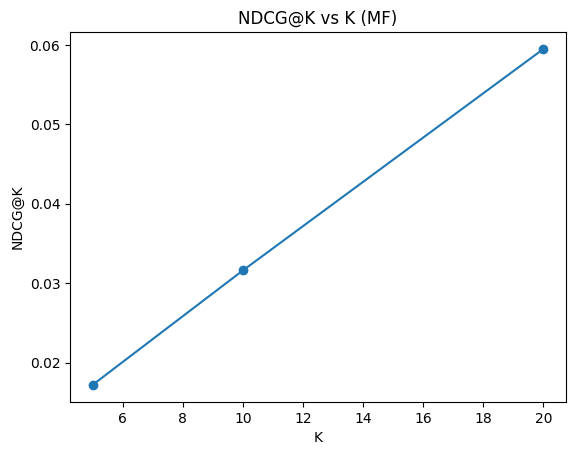

In [3]:
import matplotlib.pyplot as plt
# NDCG@K
ks = [5, 10, 20]
ndcg_vals = [
    summary_df5["NDCG@K"].iloc[0],
    summary_df10["NDCG@K"].iloc[0],
    summary_df20["NDCG@K"].iloc[0]
]

plt.figure()
plt.plot(ks, ndcg_vals, marker='o')
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.title("NDCG@K vs K (MF)")
plt.show()

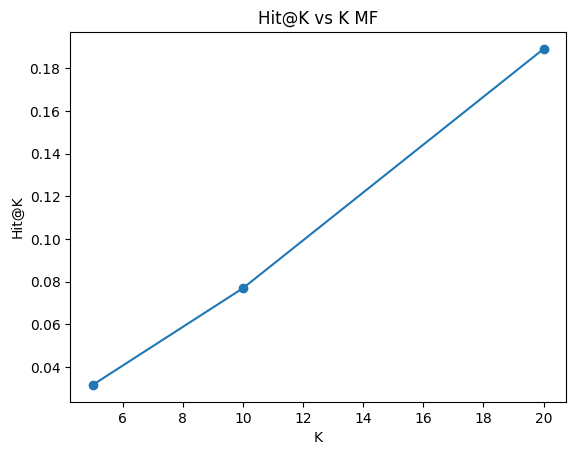

In [4]:
#Hit@K
hit_vals = [
    summary_df5["Hit@K"].iloc[0],
    summary_df10["Hit@K"].iloc[0],
    summary_df20["Hit@K"].iloc[0]
]
plt.figure()
plt.plot(ks, hit_vals, marker='o')
plt.xlabel("K")
plt.ylabel("Hit@K")
plt.title("Hit@K vs K MF")
plt.show()

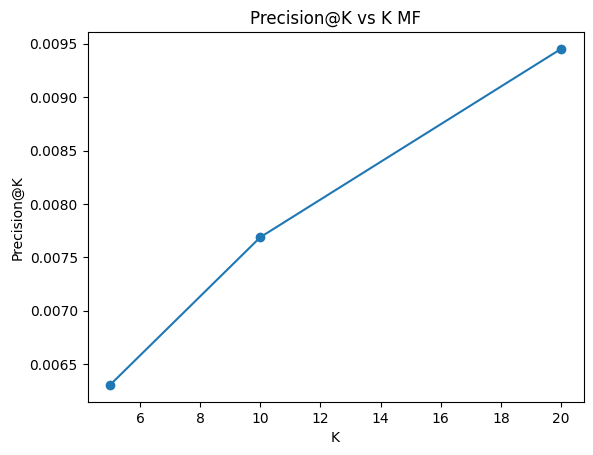

In [6]:
#Precision@K
precision_vals = [
    summary_df5["Precision@K"].iloc[0],
    summary_df10["Precision@K"].iloc[0],
    summary_df20["Precision@K"].iloc[0]
]
plt.figure()
plt.plot(ks, precision_vals, marker='o')
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Precision@K vs K MF")
plt.show()